In [10]:
# ==========================================
# FAST BERT
# ==========================================


In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt

import transformers
from datasets import load_dataset
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

if not hasattr(transformers, "PreTrainedTokenizerBase"):
    class PreTrainedTokenizerBase:
        pass

    transformers.PreTrainedTokenizerBase = PreTrainedTokenizerBase

_original_add_weight = tf.keras.layers.Layer.add_weight

def _patched_add_weight(self, *args, **kwargs):
    if args and isinstance(args[0], str) and "name" not in kwargs:
        kwargs["name"] = args[0]
        args = args[1:]
    return _original_add_weight(self, *args, **kwargs)

tf.keras.layers.Layer.add_weight = _patched_add_weight

In [18]:

# ------------------------------------------
# 1. Load Dataset (REDUCED)
# ------------------------------------------
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=42).select(range(2000))
test_data  = dataset["test"].shuffle(seed=42).select(range(800))

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))


Train samples: 2000
Test samples : 800


In [23]:
# ------------------------------------------
# 2. Tokenization (fast tiny tokenizer)
# ------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_texts = train_data["text"]
test_texts = test_data["text"]
train_labels = train_data["label"]
test_labels = test_data["label"]

max_length = 64

def tokenize_texts(texts):
    input_ids = []
    attention_masks = []
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    cls_token_id = tokenizer.cls_token_id if tokenizer.cls_token_id is not None else pad_token_id
    sep_token_id = tokenizer.sep_token_id if tokenizer.sep_token_id is not None else pad_token_id

    for text in texts:
        tokens = tokenizer.tokenize(text)
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        token_ids = [cls_token_id] + token_ids + [sep_token_id]
        token_ids = token_ids[:max_length]

        attention_mask = [1] * len(token_ids)
        padding_length = max_length - len(token_ids)
        if padding_length > 0:
            token_ids = token_ids + [pad_token_id] * padding_length
            attention_mask = attention_mask + [0] * padding_length

        input_ids.append(token_ids)
        attention_masks.append(attention_mask)

    return {
        "input_ids": np.array(input_ids),
        "attention_mask": np.array(attention_masks),
    }

import numpy as np
train_enc = tokenize_texts(train_texts)
test_enc  = tokenize_texts(test_texts)

# Convert to numpy arrays for TF dataset
train_input_ids = np.array(train_enc["input_ids"])
train_attention_mask = np.array(train_enc["attention_mask"])
train_labels = np.array(train_labels)

test_input_ids = np.array(test_enc["input_ids"])
test_attention_mask = np.array(test_enc["attention_mask"])
test_labels = np.array(test_labels)

print("Tokenized shapes:", train_input_ids.shape, train_attention_mask.shape)

Tokenized shapes: (2000, 64) (2000, 64)


In [29]:
# ------------------------------------------
# 3. Dataset -> tf.data
# ------------------------------------------
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": train_input_ids,
        "attention_mask": train_attention_mask
    },
    train_labels
)).shuffle(500).batch(32)


test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_input_ids,
        "attention_mask": test_attention_mask
    },
    test_labels
)).batch(32)

print("TF datasets ready")

TF datasets ready


In [26]:
# ------------------------------------------
# 4. SMALL BERT MODEL (VERY FAST)
# ------------------------------------------
model = TFAutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)


In [31]:
# ------------------------------------------
# 5. Compile
# ------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


In [32]:

# ------------------------------------------
# 6. Train
# ------------------------------------------
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=2
)


Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 770s 11s/step - accuracy: 0.7865 - loss: 0.6958 - val_accuracy: 0.8825 - val_loss: 0.3672
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 29499s 476s/step - accuracy: 0.9340 - loss: 0.2385 - val_accuracy: 0.9025 - val_loss: 0.3230


In [33]:

# ------------------------------------------
# 7. Evaluate
# ------------------------------------------
loss, accuracy = model.evaluate(test_dataset)

print("\nAccuracy:", accuracy)


25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9025 - loss: 0.3230

Accuracy: 0.9024999737739563


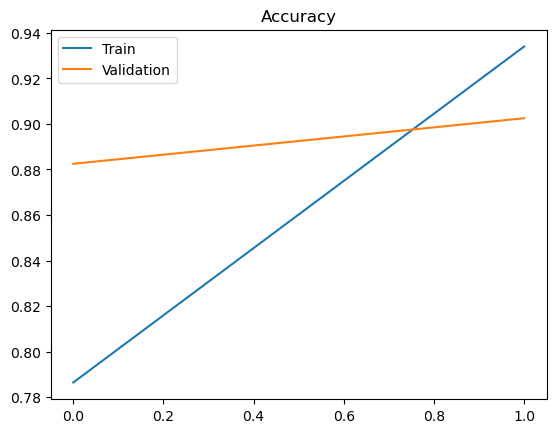

In [34]:

# ------------------------------------------
# 8. Plot
# ------------------------------------------
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.legend()
plt.title("Accuracy")
plt.show()


In [38]:
# ------------------------------------------
# 9. Prediction
# ------------------------------------------
sample = ["The stock market is booming"]

# Use the same compatible tokenization function used for training
enc = tokenize_texts(sample)
import tensorflow as tf
inputs = {
    "input_ids": tf.constant(enc["input_ids"], dtype=tf.int32),
    "attention_mask": tf.constant(enc["attention_mask"], dtype=tf.int32),
}

out = model(inputs)
# support HF output object or legacy tuple
logits = out.logits if hasattr(out, "logits") else out[0]

pred = tf.argmax(logits, axis=1).numpy()[0]

labels_map = ["World", "Sports", "Business", "Sci/Tech"]
print("Prediction:", labels_map[pred])

Prediction: Business
